In [1]:
import neurokit2 as nk
import numpy as np
import pandas as pd
from tqdm import tqdm

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm

def is_lead_corrupted(signal, sampling_rate=250, window_seconds=2, variance_threshold=1e-4):
    """
    Checks if a preprocessed, normalized lead has an extended flatline.
    """
    window_size = window_seconds * sampling_rate
    
    for i in range(0, len(signal) - window_size, sampling_rate):
        window = signal[i : i + window_size]
        if np.var(window) < variance_threshold:
            return True
            
    return False

all_waveforms = np.load("../data/EchoNext_train_waveforms.npy", mmap_mode="r")

if len(all_waveforms.shape) == 4:
    pass

num_records = all_waveforms.shape[0]
sampling_rate = 250

bad_indices = []
good_indices = []

print(f"Scanning {num_records} records for flatline artifacts...")

for idx in tqdm(range(num_records)):
    record = all_waveforms[idx, 0, :, :] 
    is_record_bad = False
    
    for lead_idx in range(12):
        lead_signal = record[:, lead_idx]
        if is_lead_corrupted(lead_signal, sampling_rate):
            is_record_bad = True
            break
            
    if is_record_bad:
        bad_indices.append(idx)
    else:
        good_indices.append(idx)

print(f"\n--- Scanning Complete ---")
print(f"Number of clean ECGs: {len(good_indices)}")
print(f"Number of flatlined/bad ECGs dropped: {len(bad_indices)}")

Scanning 72475 records for flatline artifacts...


100%|██████████| 72475/72475 [02:00<00:00, 602.86it/s]


--- Scanning Complete ---
Number of clean ECGs: 71891
Number of flatlined/bad ECGs dropped: 584


Visualizing Lead 2 for random bad indices: [12876, 2234, 33061, 29370]


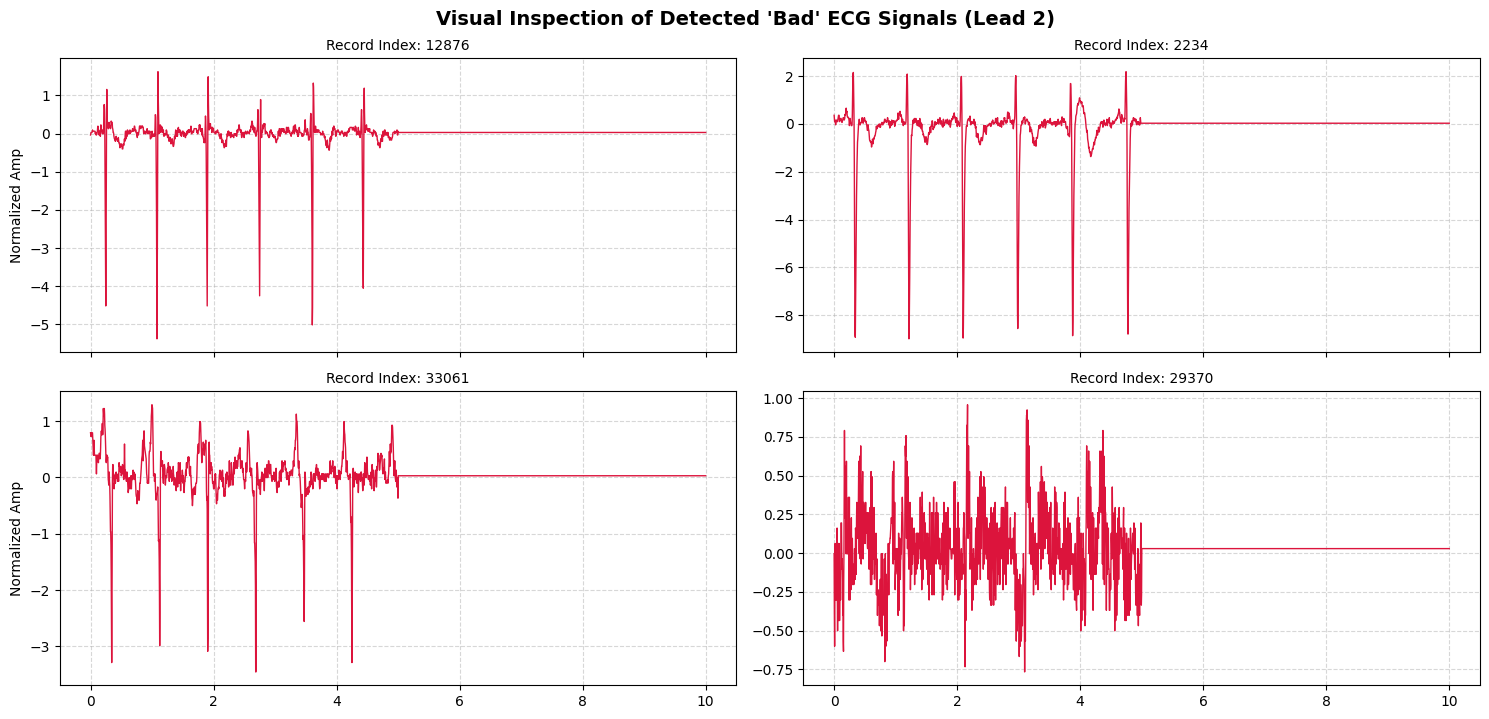

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(42)
sampled_bad_indices = random.sample(bad_indices, 4)

fig, axes = plt.subplots(2, 2, figsize=(15, 7), sharex=True)
axes = axes.flatten()

print(f"Visualizing Lead 2 for random bad indices: {sampled_bad_indices}")

for i, record_idx in enumerate(sampled_bad_indices):
    signal = all_waveforms[record_idx, 0, :, 2] 
    time = np.linspace(0, 10, len(signal))
    
    axes[i].plot(time, signal, color='crimson', linewidth=1)
    axes[i].set_title(f"Record Index: {record_idx}", fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.5)
    
    if i >= 8:
        axes[i].set_xlabel("Time (seconds)")
    if i % 2 == 0:
        axes[i].set_ylabel("Normalized Amp")

plt.tight_layout()
plt.suptitle("Visual Inspection of Detected 'Bad' ECG Signals (Lead 2)", y=1.02, fontsize=14, fontweight='bold')
plt.show()

In [4]:
# now checking how tabular features look like without bad ECGs
tabular = pd.read_csv("../data/echonext_metadata_100k.csv", index_col=0)
tabular_train = tabular[tabular["split"] == "train"].reset_index(drop=True)

In [5]:
tabular_train.head()

,ecg_key,patient_key,age_at_ecg,sex,acquisition_year,location_setting,race_ethnicity,most_recent_ecg,ventricular_rate,atrial_rate,...,tricuspid_regurgitation_value,pulmonary_regurgitation_value,rv_systolic_function_value,pericardial_effusion_value,ivs_measurement,lvpw_measurement,pasp_value,tr_max_velocity_value,lvef_value,split
0,8520052,902618160,88,male,2014,emergency,other,1,117.0,117.0,...,none,presumed none,normal,trace,1.0,1.0,NaN,NaN,62.5,train
1,7283576,4764241080,69,female,2019,inpatient,black,0,99.0,99.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train
2,8769869,4214459612,22,male,2017,inpatient,white,0,86.0,86.0,...,none,none,mildly_reduced,small,1.1,1.1,51.0,NaN,57.5,train
3,6379904,6205191619,70,male,2022,emergency,hispanic,0,68.0,68.0,...,none,none,normal,none,0.9,1.0,NaN,NaN,45.0,train
4,9619545,8380688329,54,male,2013,inpatient,other,0,90.0,93.0,...,mild,none,moderately_reduced,small,1.2,1.0,38.0,2.6,20.0,train


In [6]:
# remove bad indices from tabular_train
tabular_train_cleaned = tabular_train.drop(index=bad_indices).reset_index(drop=True)
print(f"Original training set size: {len(tabular_train)}")
print(f"Cleaned training set size (after removing bad ECGs): {len(tabular_train_cleaned)}")

Original training set size: 72475
Cleaned training set size (after removing bad ECGs): 71891


In [7]:
tabular_train_cleaned['age_at_ecg'].describe()

count    71891.000000
mean        61.313196
std         16.015663
min         18.000000
25%         52.000000
50%         63.000000
75%         73.000000
max         90.000000
Name: age_at_ecg, dtype: float64

In [8]:
tabular_train_cleaned['ventricular_rate'].describe()

count    71891.000000
mean        83.432738
std         20.429456
min         24.000000
25%         69.000000
50%         81.000000
75%         95.000000
max        223.000000
Name: ventricular_rate, dtype: float64

In [10]:
tabular_train_cleaned['atrial_rate'].describe()

count    71439.000000
mean        89.881283
std         44.126746
min          0.000000
25%         69.000000
50%         81.000000
75%         97.000000
max        576.000000
Name: atrial_rate, dtype: float64

In [13]:
tabular_train_cleaned['pr_interval'].describe()

count    64282.000000
mean       159.708208
std         32.416258
min         30.000000
25%        138.000000
50%        154.000000
75%        174.000000
max        544.000000
Name: pr_interval, dtype: float64

In [14]:
tabular_train_cleaned['pr_interval'].nsmallest(15)

13706    30.0
30277    46.0
41962    48.0
54139    48.0
50751    52.0
20641    56.0
22265    56.0
36385    56.0
37989    56.0
59309    56.0
23504    58.0
4165     64.0
8378     64.0
9700     64.0
13410    64.0
Name: pr_interval, dtype: float64

Patient ID: 13706
PR Interval: 30.0
Waveform index in cleaned data: 13588


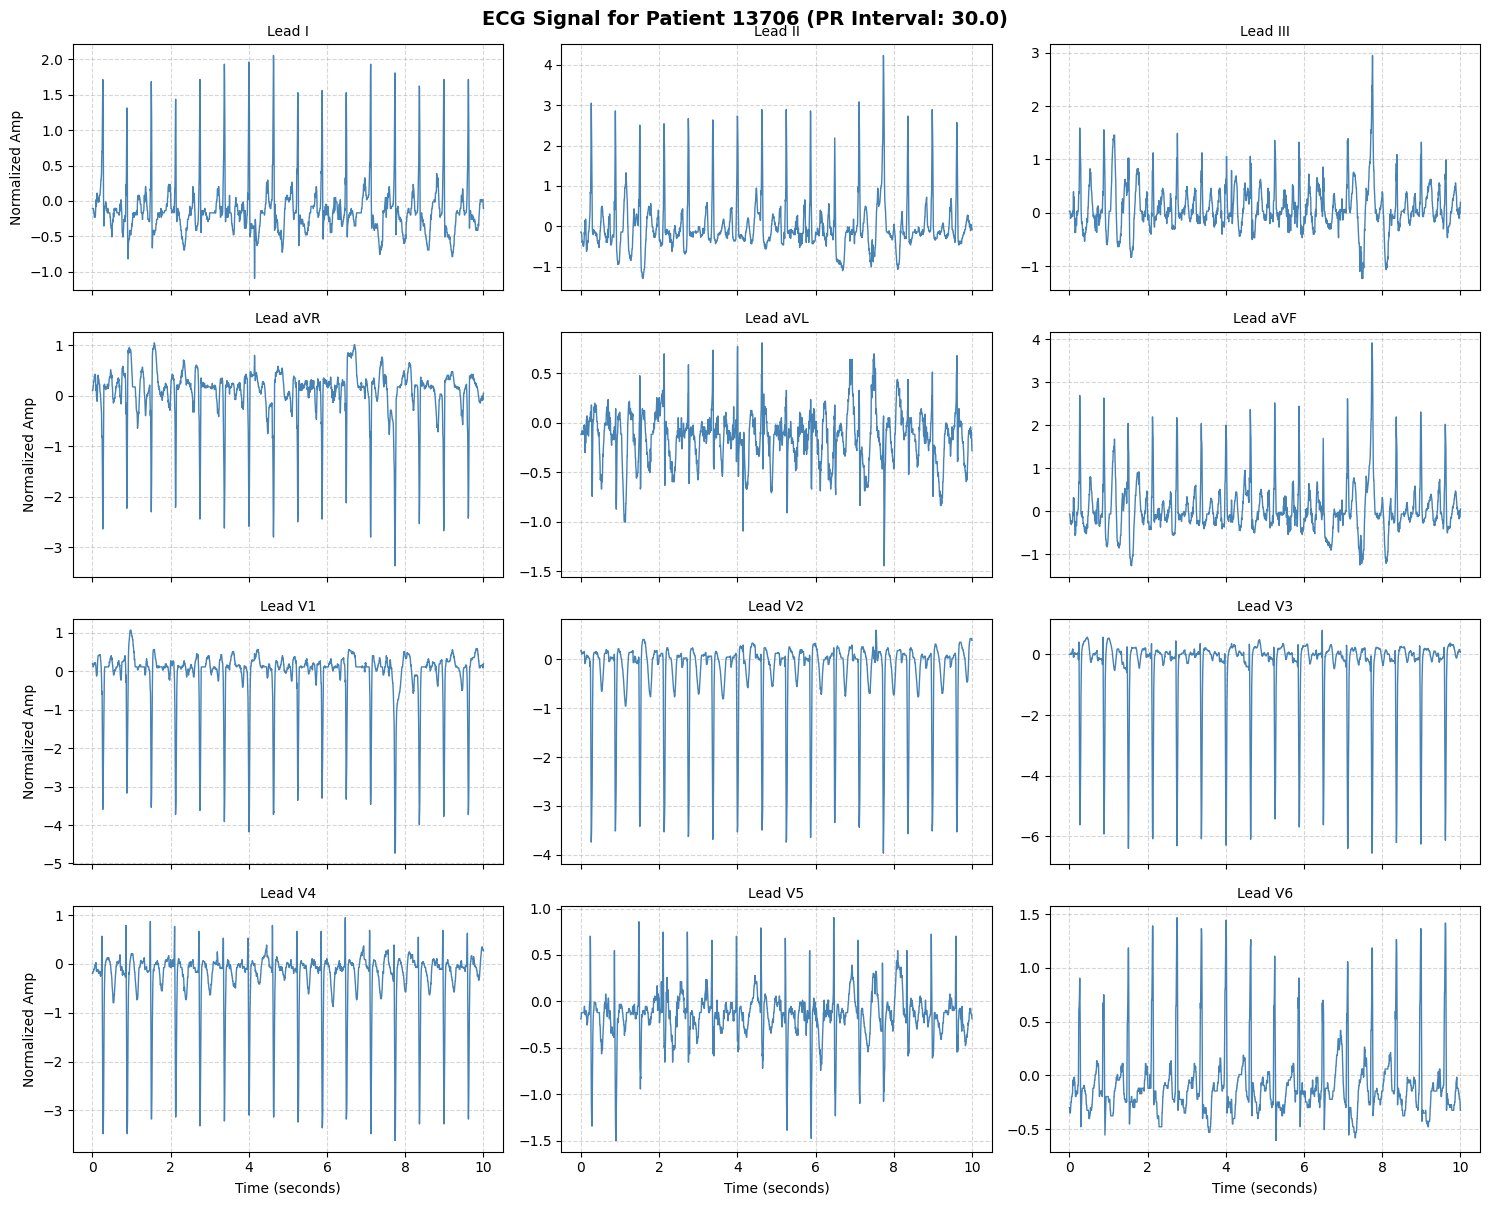

In [ ]:
patient_id = 13706
patient_row = tabular_train_cleaned[tabular_train_cleaned.index == patient_id]

if len(patient_row) > 0:
    original_index = patient_id
    removed_before = len([idx for idx in bad_indices if idx < original_index])
    waveform_index = original_index - removed_before
    
    print(f"Patient ID: {patient_id}")
    print(f"PR Interval: {patient_row['pr_interval'].values[0]}")
    print(f"Waveform index in cleaned data: {waveform_index}")
    
    signal = all_waveforms[waveform_index, 0, :, :]
    time = np.linspace(0, 10, signal.shape[0])
    
    fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True)
    axes = axes.flatten()
    
    lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    
    for lead_idx in range(12):
        lead_signal = signal[:, lead_idx]
        axes[lead_idx].plot(time, lead_signal, color='steelblue', linewidth=1)
        axes[lead_idx].set_title(f"Lead {lead_names[lead_idx]}", fontsize=10)
        axes[lead_idx].grid(True, linestyle='--', alpha=0.5)
        
        if lead_idx >= 9:
            axes[lead_idx].set_xlabel("Time (seconds)")
        if lead_idx % 3 == 0:
            axes[lead_idx].set_ylabel("Normalized Amp")
    
    plt.tight_layout()
    plt.suptitle(f"ECG Signal for Patient {patient_id} (PR Interval: {patient_row['pr_interval'].values[0]})", 
                 y=1.00, fontsize=14, fontweight='bold')
    plt.show()
else:
    print(f"Patient ID {patient_id} not found in cleaned dataset")

In [15]:
tabular_train_cleaned['qrs_duration'].describe()

count    71891.000000
mean        94.866339
std         21.904622
min          4.000000
25%         80.000000
50%         90.000000
75%        102.000000
max        254.000000
Name: qrs_duration, dtype: float64

In [16]:
tabular_train_cleaned['qrs_duration'].nsmallest(25)

1246      4.0
4461      4.0
6577      4.0
7454      4.0
15671     4.0
22240     4.0
49058     4.0
16835     8.0
23504     8.0
34489    12.0
12238    14.0
40293    24.0
24699    26.0
25193    32.0
45165    32.0
38359    34.0
44392    34.0
33009    42.0
60213    44.0
14260    48.0
38528    48.0
40947    48.0
43629    48.0
3986     50.0
8113     50.0
Name: qrs_duration, dtype: float64

Patient 1246: QRS Duration = 4.0
Patient 4461: QRS Duration = 4.0
Patient 6577: QRS Duration = 4.0
Patient 7454: QRS Duration = 4.0


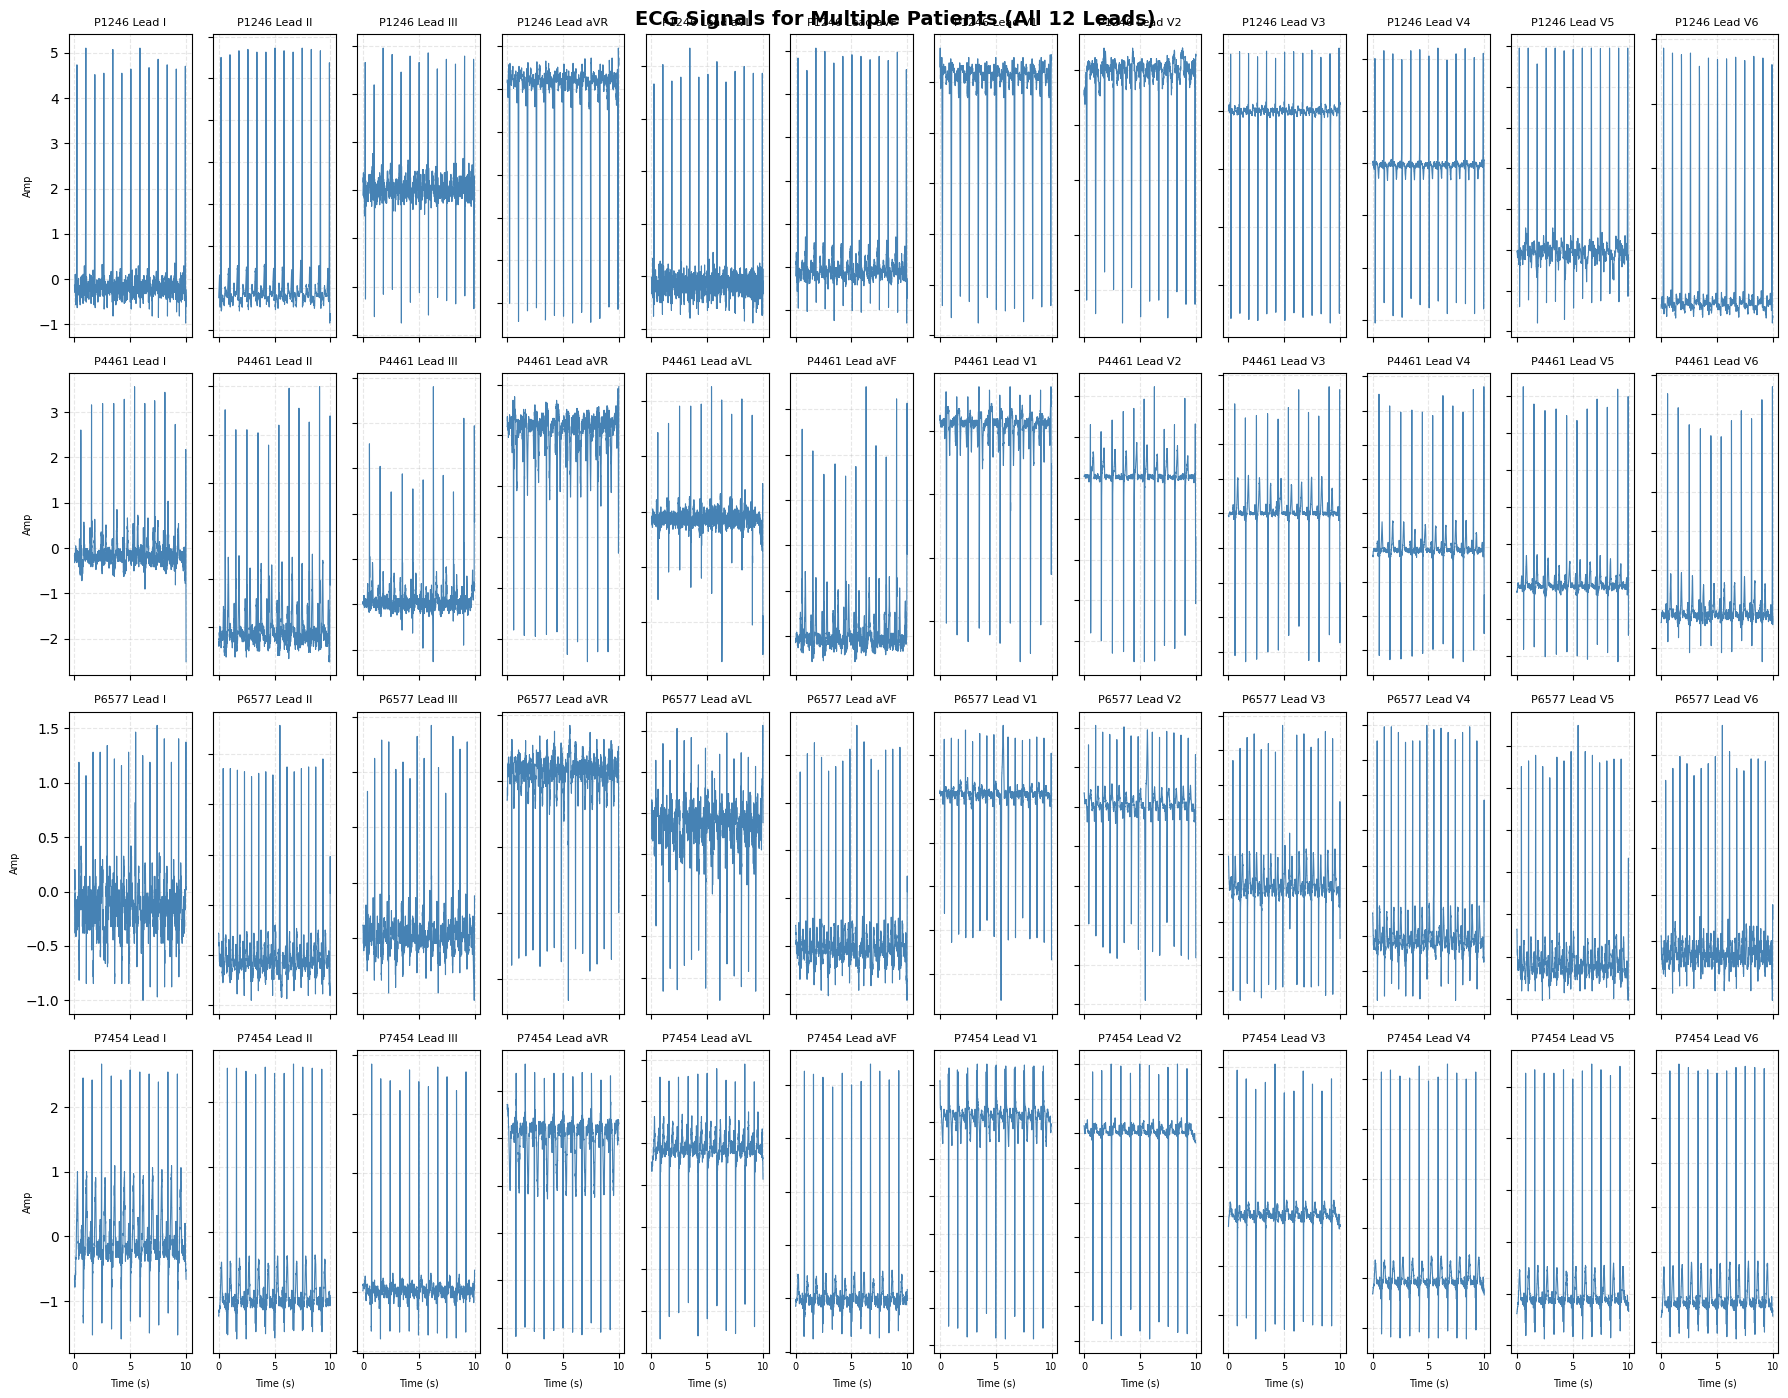

In [ ]:
patient_ids = [1246, 4461, 6577, 7454]
fig = plt.figure(figsize=(18, 14))

lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
time = np.linspace(0, 10, 2500)

for patient_num, patient_id in enumerate(patient_ids):
    patient_row = tabular_train_cleaned[tabular_train_cleaned.index == patient_id]
    
    if len(patient_row) > 0:
        original_index = patient_id
        removed_before = len([idx for idx in bad_indices if idx < original_index])
        waveform_index = original_index - removed_before
        
        signal = all_waveforms[waveform_index, 0, :, :]
        
        for lead_idx in range(12):
            ax = plt.subplot(4, 12, patient_num * 12 + lead_idx + 1)
            lead_signal = signal[:, lead_idx]
            ax.plot(time, lead_signal, color='steelblue', linewidth=0.8)
            ax.set_title(f"P{patient_id} Lead {lead_names[lead_idx]}", fontsize=8)
            ax.grid(True, linestyle='--', alpha=0.3)
            ax.set_xticks([0, 5, 10])
            ax.set_xticklabels(['0', '5', '10'], fontsize=7)
            
            if lead_idx % 12 == 0:
                ax.set_ylabel("Amp", fontsize=7)
            else:
                ax.set_yticklabels([])
            
            if patient_num < 3:
                ax.set_xticklabels([])
            else:
                ax.set_xlabel("Time (s)", fontsize=7)
        
        qrs_duration = patient_row['qrs_duration'].values[0]
        print(f"Patient {patient_id}: QRS Duration = {qrs_duration}")

plt.tight_layout()
plt.suptitle("ECG Signals for Multiple Patients (All 12 Leads)", y=0.995, fontsize=14, fontweight='bold')
plt.show()

In [17]:
tabular_train_cleaned['qt_corrected'].describe()

count    71890.000000
mean       453.116484
std         40.075349
min         95.000000
25%        427.000000
50%        449.000000
75%        474.000000
max        771.000000
Name: qt_corrected, dtype: float64

overall data quality in tabular features seems to slightly improve after removing thos with flat lines - i feel not knowledgeble enough to remove outliers based only on tabular features. so removing based on variance will be added to pipeline